In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

100%|██████████| 1.26G/1.26G [01:15<00:00, 17.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("/root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv",
    nrows=150000,
    low_memory=False
)

print(df.shape)
df.head()

(150000, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['target'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

print(df['target'].value_counts())

target
0    105691
1     26330
Name: count, dtype: int64


In [5]:
selected_cols = [

    'loan_amnt',
    'term',
    'int_rate',
    'grade',
    'sub_grade',
    'emp_length',
    'annual_inc',
    'dti',
    'fico_range_low',
    'fico_range_high',
    'open_acc',
    'pub_rec',
    'revol_util',
    'total_acc',
    'mort_acc',
    'pub_rec_bankruptcies',
    'delinq_2yrs',

    'loan_status',
    'target'
]

df = df[selected_cols]

In [7]:
df = df[
    df['loan_status'].isin(
        ['Fully Paid', 'Charged Off']
    )
]

df['target'] = df['loan_status'].apply(
    lambda x: 1 if x == 'Charged Off' else 0
)

In [8]:
df['emp_length'] = (
    df['emp_length']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

df['emp_length'] = pd.to_numeric(
    df['emp_length'],
    errors='coerce'
)

df['emp_length'] = df['emp_length'].fillna(
    df['emp_length'].median()
)

In [9]:
for col in df.columns:

    if df[col].dtype == 'object':

        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])

    else:

        df[col] = df[col].fillna(df[col].median())

In [10]:
X = df.drop(columns=['target', 'loan_status'])

y = df['target']

In [11]:
X = pd.get_dummies(
    X,
    columns=['term', 'grade', 'sub_grade'],
    drop_first=True
)

In [12]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [13]:
df['int_rate'] = pd.to_numeric(
    df['int_rate'],
    errors='coerce'
)

In [14]:
print(df.isnull().sum())

loan_amnt               0
term                    0
int_rate                0
grade                   0
sub_grade               0
emp_length              0
annual_inc              0
dti                     0
fico_range_low          0
fico_range_high         0
open_acc                0
pub_rec                 0
revol_util              0
total_acc               0
mort_acc                0
pub_rec_bankruptcies    0
delinq_2yrs             0
loan_status             0
target                  0
dtype: int64


In [15]:
X = df.drop(columns=['target', 'loan_status'])

y = df['target']

In [16]:
for col in df.columns:

    if df[col].dtype == 'object':

        if not df[col].mode().empty:
            df[col] = df[col].fillna(df[col].mode()[0])

    else:

        df[col] = df[col].fillna(df[col].median())

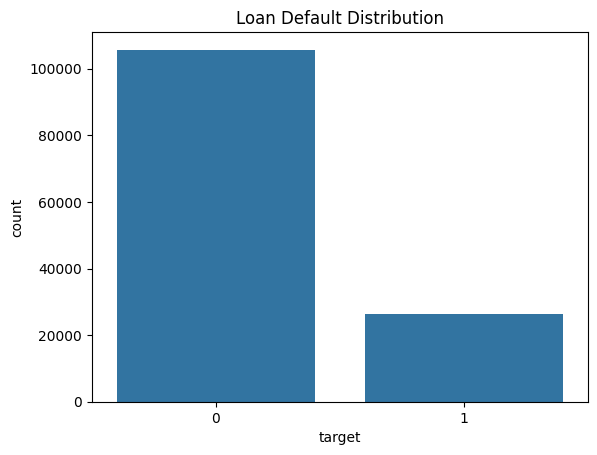

In [17]:
sns.countplot(x='target', data=df)

plt.title("Loan Default Distribution")

plt.show()

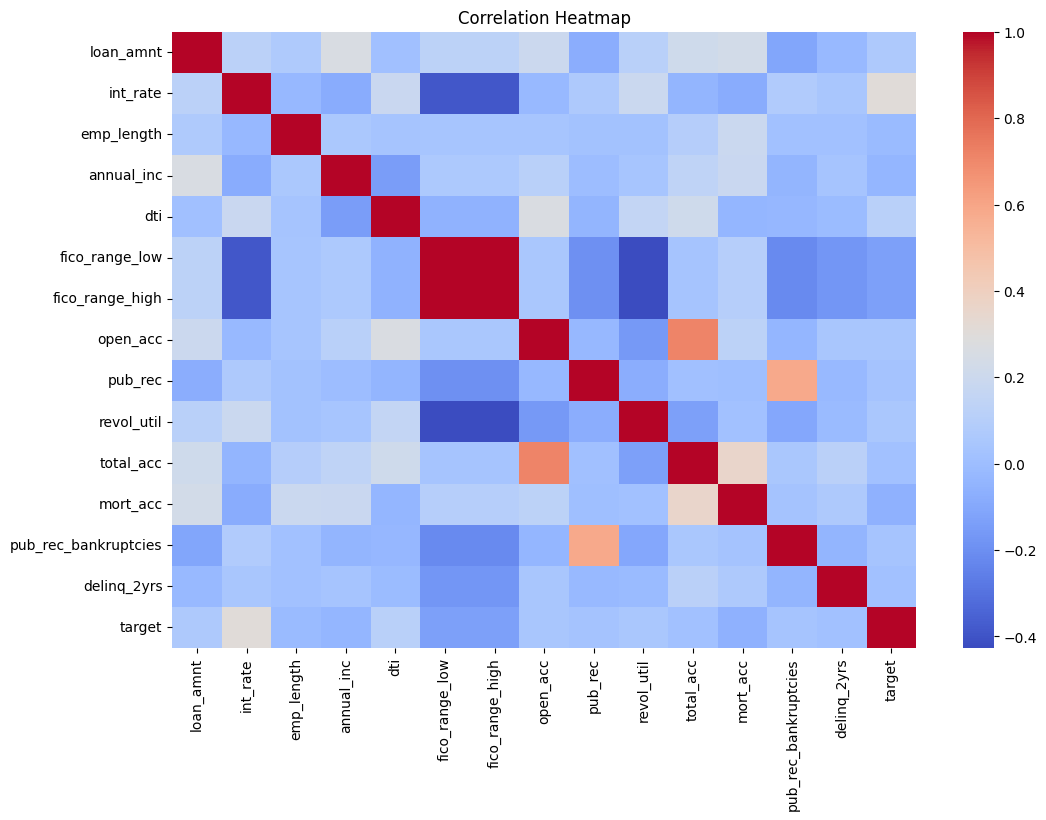

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
df['emp_length'] = (
    df['emp_length']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

df['emp_length'] = pd.to_numeric(
    df['emp_length'],
    errors='coerce'
)

df['emp_length'] = df['emp_length'].fillna(
    df['emp_length'].median()
)

In [20]:
print(df['emp_length'].head())

print(df['emp_length'].dtype)

0    10
1    10
2    10
4     3
5     4
Name: emp_length, dtype: int64
int64


In [21]:
df['emp_length'] = df['emp_length'].fillna(
    df['emp_length'].median()
)

In [22]:
X = df.drop(columns=['target', 'loan_status'])

y = df['target']

In [23]:
X = pd.get_dummies(
    X,
    columns=['term', 'grade', 'sub_grade'],
    drop_first=True
)

In [24]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [29]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train_smote)

LogisticRegression(max_iter=1000)

In [30]:
y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_pred_lr))

Accuracy: 0.8012497633024048
              precision    recall  f1-score   support

           0       0.82      0.96      0.89     21077
           1       0.52      0.18      0.27      5328

    accuracy                           0.80     26405
   macro avg       0.67      0.57      0.58     26405
weighted avg       0.76      0.80      0.76     26405

[[20194   883]
 [ 4365   963]]
ROC-AUC: 0.56942461777857


In [31]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42)

In [32]:
y_pred_rf = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_pred_rf))

Accuracy: 0.7874644953607272
              precision    recall  f1-score   support

           0       0.84      0.91      0.87     21077
           1       0.46      0.30      0.36      5328

    accuracy                           0.79     26405
   macro avg       0.65      0.60      0.62     26405
weighted avg       0.76      0.79      0.77     26405

[[19211  1866]
 [ 3746  1582]]
ROC-AUC: 0.6041946991589967


In [33]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
y_prob = xgb.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.55).astype(int)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, y_pred))

Accuracy: 0.7320204506722212
              precision    recall  f1-score   support

           0       0.86      0.79      0.82     21077
           1       0.38      0.51      0.44      5328

    accuracy                           0.73     26405
   macro avg       0.62      0.65      0.63     26405
weighted avg       0.77      0.73      0.75     26405

[[16596  4481]
 [ 2595  2733]]
ROC-AUC: 0.6501745182934986


In [ ]:
!pip install shap

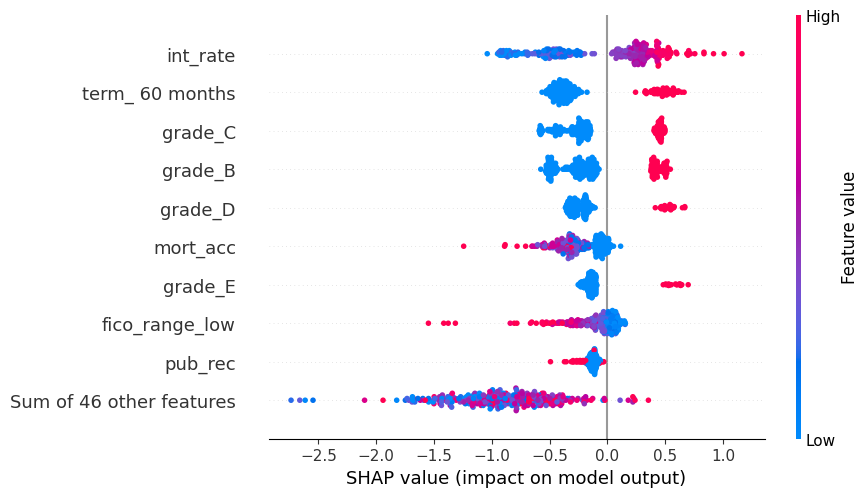

In [35]:
import shap

# Use only a sample of rows for faster SHAP processing
sample_X = X_test.sample(300, random_state=42)

# Create SHAP explainer
explainer = shap.Explainer(xgb)

# Generate SHAP values
shap_values = explainer(sample_X)

# Beeswarm plot
shap.plots.beeswarm(shap_values)

In [36]:
prob = xgb.predict_proba(X_test)[:,1]

risk_score = prob * 100

def risk_category(score):
    if score < 35:
        return "Low Risk"
    elif score < 70:
        return "Medium Risk"
    else:
        return "High Risk"

risk_labels = [risk_category(x) for x in risk_score]

In [37]:
def recommendation(score):
    if score < 35:
        return "Approve"
    elif score < 70:
        return "Manual Review"
    else:
        return "Reject"

In [38]:
import joblib

joblib.dump(
    xgb,
    "xgboost_loan_model.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "model_columns.pkl"
)

threshold = 0.55

joblib.dump(
    threshold,
    "threshold.pkl"
)

print("Final production model saved!")

Final production model saved!


In [39]:
df.to_csv("cleaned_loan_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [40]:
import os

print(os.getcwd())

/content


In [41]:
predictions_df = X_test.copy()

predictions_df['Actual_Default'] = y_test.values

predictions_df['Predicted_Probability'] = y_prob

predictions_df['Predicted_Default'] = y_pred

predictions_df['Risk_Category'] = predictions_df['Predicted_Probability'].apply(
    lambda x: (
        'Low Risk' if x < 0.35
        else 'Medium Risk' if x < 0.65
        else 'High Risk'
    )
)

predictions_df['Recommendation'] = predictions_df['Risk_Category'].map({
    'Low Risk': 'Approved',
    'Medium Risk': 'Manual Review',
    'High Risk': 'Rejected'
})

predictions_df.to_csv(
    "loan_risk_dashboard_data.csv",
    index=False
)

print("Power BI dataset created successfully!")

Power BI dataset created successfully!


In [42]:
from google.colab import files

files.download("loan_risk_dashboard_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>